# Output Metrics Data Analysis 

This notebook analyzes the evaluation results of a single language model across different prompt types.

The analysis is based on the output metrics produced by the evaluation pipeline, using both global metrics and category-level metrics. The goal is to compare how different prompt formulations affect model behavior in terms of response validity, format compliance, answer correctness, unknown-answer behavior, and fairness-related tendencies.

In particular, the notebook focuses on:

- **Response validity and format compliance**, to verify whether the model produces parseable answers and follows the required output structure.
- **Check-status behavior**, by comparing how often the model outputs `UNDERSTOOD`, `NOT_UNDERSTOOD`, or an invalid/missing check status.
- **Unknown-answer behavior**, to understand whether some prompt types or categories make the model more likely to select the `unknown` option.
- **Accuracy on valid predictions**, used as the main accuracy measure because it separates answer correctness from formatting or parsing failures.
- **Stereotype-direction behavior**, measured through `sDIS` and related direction ratios.
- **Nonaligned biased errors**, which are especially important because they measure whether the model follows a stereotype when the correct answer goes against it.
- **Category-level differences**, to identify whether model behavior changes across sensitive categories.


## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

# Change this value to analyze another model.
# Expected examples: "llama31_8b", "qwen3_8b", "ministral3_8b"
MODEL_NAME = "qwen3_8b"

EVALUATION_DIR = Path("../experiments/evaluations")

OUTPUT_METRICS_BY_RUN_FILE = EVALUATION_DIR / "output_metrics_by_run.csv"
GLOBAL_METRICS_SUMMARY_FILE = EVALUATION_DIR / "global_metrics_summary.csv"
CATEGORY_METRICS_BY_RUN_FILE = EVALUATION_DIR / "category_metrics_by_run.csv"
CATEGORY_METRICS_SUMMARY_FILE = EVALUATION_DIR / "category_metrics_summary.csv"

EXPORT_DIR = EVALUATION_DIR / "notebook_analysis_tables" / MODEL_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Selected model: {MODEL_NAME}")
print(f"Export directory: {EXPORT_DIR}")


Selected model: qwen3_8b
Export directory: ..\experiments\evaluations\notebook_analysis_tables\qwen3_8b


## 2. Load Data

The helper function strips whitespace from column names. This is useful if CSV headers contain accidental spaces after commas.


In [2]:
def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(path, encoding="utf-8-sig", skipinitialspace=True)
    df.columns = [str(column).strip() for column in df.columns]

    # Strip whitespace from textual columns only.
    for column in df.columns:
        if pd.api.types.is_string_dtype(df[column]):
            df[column] = df[column].str.strip()

    return df


output_by_run_all_df = load_csv(OUTPUT_METRICS_BY_RUN_FILE)
global_summary_all_df = load_csv(GLOBAL_METRICS_SUMMARY_FILE)
category_by_run_all_df = load_csv(CATEGORY_METRICS_BY_RUN_FILE)
category_summary_all_df = load_csv(CATEGORY_METRICS_SUMMARY_FILE)

print("output_by_run_all_df:", output_by_run_all_df.shape)
print("global_summary_all_df:", global_summary_all_df.shape)
print("category_by_run_all_df:", category_by_run_all_df.shape)
print("category_summary_all_df:", category_summary_all_df.shape)


output_by_run_all_df: (150, 29)
global_summary_all_df: (15, 107)
category_by_run_all_df: (1650, 30)
category_summary_all_df: (165, 108)


## 3. Filter Selected Model

In [3]:
def require_model(df: pd.DataFrame, model_name: str, df_name: str) -> pd.DataFrame:
    if "model" not in df.columns:
        raise ValueError(f"{df_name} does not contain a 'model' column.")

    available_models = sorted(df["model"].dropna().unique().tolist())

    if model_name not in available_models:
        raise ValueError(
            f"Model '{model_name}' not found in {df_name}. "
            f"Available models: {available_models}"
        )

    return df[df["model"] == model_name].copy()


output_by_run_df = require_model(output_by_run_all_df, MODEL_NAME, "output_by_run_all_df")
global_summary_df = require_model(global_summary_all_df, MODEL_NAME, "global_summary_all_df")
category_by_run_df = require_model(category_by_run_all_df, MODEL_NAME, "category_by_run_all_df")
category_summary_df = require_model(category_summary_all_df, MODEL_NAME, "category_summary_all_df")

print("output_by_run_df:", output_by_run_df.shape)
print("global_summary_df:", global_summary_df.shape)
print("category_by_run_df:", category_by_run_df.shape)
print("category_summary_df:", category_summary_df.shape)


output_by_run_df: (50, 29)
global_summary_df: (5, 107)
category_by_run_df: (550, 30)
category_summary_df: (55, 108)


In [4]:
display(output_by_run_df.head())
display(global_summary_df.head())
display(category_by_run_df.head())
display(category_summary_df.head())


,model,prompt_type,run,records_total,understood_total,not_understood_total,invalid_check_status_total,valid_ratio,invalid_ratio,format_valid_ratio,unknown_over_total_ratio,unknown_over_valid_ratio,accuracy,accuracy_valid_only,accuracy_aligned,accuracy_nonaligned,accuracy_cost_bias_nonalignment,non_unknown_valid_predictions_total,aligned_total,nonaligned_total,stereotype_direction_prediction_total,anti_stereotype_direction_prediction_total,stereotype_direction_ratio,anti_stereotype_direction_ratio,sdis,biased_errors_total,biased_error_rate_nonaligned,unbiased_success_nonaligned_total,unbiased_success_rate_nonaligned
100,qwen3_8b,attribute_early,1,594,586,0,8,1.0,0.0,0.986532,0.077441,0.077441,0.875421,0.875421,0.882155,0.868687,-0.013468,548,297,297,274,274,0.500000,0.500000,0.000000,12,0.044444,258,0.955556
101,qwen3_8b,attribute_early,2,594,585,0,9,1.0,0.0,0.984848,0.082492,0.082492,0.870370,0.870370,0.875421,0.865320,-0.010101,545,297,297,272,273,0.499083,0.500917,-0.001835,12,0.044610,257,0.955390
102,qwen3_8b,attribute_early,3,594,585,0,9,1.0,0.0,0.984848,0.080808,0.080808,0.872054,0.872054,0.878788,0.865320,-0.013468,546,297,297,273,273,0.500000,0.500000,0.000000,12,0.044610,257,0.955390
103,qwen3_8b,attribute_early,4,594,583,0,11,1.0,0.0,0.981481,0.080808,0.080808,0.872054,0.872054,0.872054,0.872054,0.000000,546,297,297,271,275,0.496337,0.503663,-0.007326,12,0.044280,259,0.955720
104,qwen3_8b,attribute_early,5,594,585,0,9,1.0,0.0,0.984848,0.077441,0.077441,0.877104,0.877104,0.882155,0.872054,-0.010101,548,297,297,274,274,0.500000,0.500000,0.000000,12,0.044280,259,0.955720


,model,prompt_type,runs_total,records_total_mean,records_total_std,records_total_min,records_total_max,understood_total_mean,understood_total_std,understood_total_min,understood_total_max,not_understood_total_mean,not_understood_total_std,not_understood_total_min,not_understood_total_max,invalid_check_status_total_mean,invalid_check_status_total_std,invalid_check_status_total_min,invalid_check_status_total_max,valid_ratio_mean,valid_ratio_std,valid_ratio_min,valid_ratio_max,invalid_ratio_mean,invalid_ratio_std,invalid_ratio_min,invalid_ratio_max,format_valid_ratio_mean,format_valid_ratio_std,format_valid_ratio_min,format_valid_ratio_max,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_total_ratio_min,unknown_over_total_ratio_max,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,unknown_over_valid_ratio_min,unknown_over_valid_ratio_max,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,accuracy_valid_only_mean,accuracy_valid_only_std,accuracy_valid_only_min,accuracy_valid_only_max,accuracy_aligned_mean,accuracy_aligned_std,accuracy_aligned_min,accuracy_aligned_max,accuracy_nonaligned_mean,accuracy_nonaligned_std,accuracy_nonaligned_min,accuracy_nonaligned_max,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,accuracy_cost_bias_nonalignment_min,accuracy_cost_bias_nonalignment_max,non_unknown_valid_predictions_total_mean,non_unknown_valid_predictions_total_std,non_unknown_valid_predictions_total_min,non_unknown_valid_predictions_total_max,aligned_total_mean,aligned_total_std,aligned_total_min,aligned_total_max,nonaligned_total_mean,nonaligned_total_std,nonaligned_total_min,nonaligned_total_max,stereotype_direction_prediction_total_mean,stereotype_direction_prediction_total_std,stereotype_direction_prediction_total_min,stereotype_direction_prediction_total_max,anti_stereotype_direction_prediction_total_mean,anti_stereotype_direction_prediction_total_std,anti_stereotype_direction_prediction_total_min,anti_stereotype_direction_prediction_total_max,stereotype_direction_ratio_mean,stereotype_direction_ratio_std,stereotype_direction_ratio_min,stereotype_direction_ratio_max,anti_stereotype_direction_ratio_mean,anti_stereotype_direction_ratio_std,anti_stereotype_direction_ratio_min,anti_stereotype_direction_ratio_max,sdis_mean,sdis_std,sdis_min,sdis_max,biased_errors_total_mean,biased_errors_total_std,biased_errors_total_min,biased_errors_total_max,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,biased_error_rate_nonaligned_min,biased_error_rate_nonaligned_max,unbiased_success_nonaligned_total_mean,unbiased_success_nonaligned_total_std,unbiased_success_nonaligned_total_min,unbiased_success_nonaligned_total_max,unbiased_success_rate_nonaligned_mean,unbiased_success_rate_nonaligned_std,unbiased_success_rate_nonaligned_min,unbiased_success_rate_nonaligned_max
10,qwen3_8b,attribute_early,10,594.0,0.0,594,594,585.3,1.337494,583,588,0.0,0.0,0,0,8.7,1.337494,6,11,1.000000,0.000000,1.000000,1.0,0.000000,0.000000,0.0,0.000000,0.985354,0.002252,0.981481,0.989899,0.079125,0.001775,0.077441,0.082492,0.079125,0.001775,0.077441,0.082492,0.873906,0.002016,0.870370,0.877104,0.873906,0.002016,0.870370,0.877104,0.877778,0.003194,0.872054,0.882155,0.870034,0.003253,0.865320,0.875421,-0.007744,0.005032,-0.013468,0.000000,547.0,1.054093,545,548,297.0,0.0,297,297,297.0,0.0,297,297,272.6,1.074968,271,274,274.4,1.264911,273,277,0.498355,0.001915,0.494526,0.500000,0.501645,0.001915,0.500000,0.505474,-0.003289,0.003830,-0.010949,0.000000,11.9,0.316228,11,12,0.044026,0.001214,0.040590,0.044610,258.4,0.966092,257,260,0.955974,0.001214,0.955390,0.959410
11,qwen3_8b,attribute_late,10,594.0,0.0,594,594,586.9,1.852926,582,588,0.0,0.0,0,0,7.1,1.852926,6,12,1.000000,0.000000,1.000000,1.0,0.000000,0.000000,0.0,0.000000,0.988047,0.003119,0.979798,0.989899,0.125926,0.002069,0.121212,0.129630,0.125926,0.002069,0.121212,0.129630,0.838215,0.002166,0.835017,0.843434,0.838215,0.002166,0.835017,0.843434,0

,model,prompt_type,run,category,records_total,understood_total,not_understood_total,invalid_check_status_total,valid_ratio,invalid_ratio,format_valid_ratio,unknown_over_total_ratio,unknown_over_valid_ratio,accuracy,accuracy_valid_only,accuracy_aligned,accuracy_nonaligned,accuracy_cost_bias_nonalignment,non_unknown_valid_predictions_total,aligned_total,nonaligned_total,stereotype_direction_prediction_total,anti_stereotype_direction_prediction_total,stereotype_direction_ratio,anti_stereotype_direction_ratio,sdis,biased_errors_total,biased_error_rate_nonaligned,unbiased_success_nonaligned_total,unbiased_success_rate_nonaligned
1100,qwen3_8b,attribute_early,1,Age,54,53,0,1,1.0,0.0,0.981481,0.018519,0.018519,0.925926,0.925926,0.962963,0.888889,-0.074074,53,27,27,28,25,0.528302,0.471698,0.056604,2,0.076923,24,0.923077
1101,qwen3_8b,attribute_early,2,Age,54,53,0,1,1.0,0.0,0.981481,0.018519,0.018519,0.925926,0.925926,0.962963,0.888889,-0.074074,53,27,27,28,25,0.528302,0.471698,0.056604,2,0.076923,24,0.923077
1102,qwen3_8b,attribute_early,3,Age,54,53,0,1,1.0,0.0,0.981481,0.018519,0.018519,0.925926,0.925926,0.962963,0.888889,-0.074074,53,27,27,28,25,0.528302,0.471698,0.056604,2,0.076923,24,0.923077
1103,qwen3_8b,attribute_early,4,Age,54,53,0,1,1.0,0.0,0.981481,0.018519,0.018519,0.925926,0.925926,0.962963,0.888889,-0.074074,53,27,27,28,25,0.528302,0.471698,0.056604,2,0.076923,24,0.923077
1104,qwen3_8b,attribute_early,5,Age,54,53,0,1,1.0,0.0,0.981481,0.018519,0.018519,0.925926,0.925926,0.962963,0.888889,-0.074074,53,27,27,28,25,0.528302,0.471698,0.056604,2,0.076923,24,0.923077


,model,prompt_type,category,runs_total,records_total_mean,records_total_std,records_total_min,records_total_max,understood_total_mean,understood_total_std,understood_total_min,understood_total_max,not_understood_total_mean,not_understood_total_std,not_understood_total_min,not_understood_total_max,invalid_check_status_total_mean,invalid_check_status_total_std,invalid_check_status_total_min,invalid_check_status_total_max,valid_ratio_mean,valid_ratio_std,valid_ratio_min,valid_ratio_max,invalid_ratio_mean,invalid_ratio_std,invalid_ratio_min,invalid_ratio_max,format_valid_ratio_mean,format_valid_ratio_std,format_valid_ratio_min,format_valid_ratio_max,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_total_ratio_min,unknown_over_total_ratio_max,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,unknown_over_valid_ratio_min,unknown_over_valid_ratio_max,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,accuracy_valid_only_mean,accuracy_valid_only_std,accuracy_valid_only_min,accuracy_valid_only_max,accuracy_aligned_mean,accuracy_aligned_std,accuracy_aligned_min,accuracy_aligned_max,accuracy_nonaligned_mean,accuracy_nonaligned_std,accuracy_nonaligned_min,accuracy_nonaligned_max,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,accuracy_cost_bias_nonalignment_min,accuracy_cost_bias_nonalignment_max,non_unknown_valid_predictions_total_mean,non_unknown_valid_predictions_total_std,non_unknown_valid_predictions_total_min,non_unknown_valid_predictions_total_max,aligned_total_mean,aligned_total_std,aligned_total_min,aligned_total_max,nonaligned_total_mean,nonaligned_total_std,nonaligned_total_min,nonaligned_total_max,stereotype_direction_prediction_total_mean,stereotype_direction_prediction_total_std,stereotype_direction_prediction_total_min,stereotype_direction_prediction_total_max,anti_stereotype_direction_prediction_total_mean,anti_stereotype_direction_prediction_total_std,anti_stereotype_direction_prediction_total_min,anti_stereotype_direction_prediction_total_max,stereotype_direction_ratio_mean,stereotype_direction_ratio_std,stereotype_direction_ratio_min,stereotype_direction_ratio_max,anti_stereotype_direction_ratio_mean,anti_stereotype_direction_ratio_std,anti_stereotype_direction_ratio_min,anti_stereotype_direction_ratio_max,sdis_mean,sdis_std,sdis_min,sdis_max,biased_errors_total_mean,biased_errors_total_std,biased_errors_total_min,biased_errors_total_max,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,biased_error_rate_nonaligned_min,biased_error_rate_nonaligned_max,unbiased_success_nonaligned_total_mean,unbiased_success_nonaligned_total_std,unbiased_success_nonaligned_total_min,unbiased_success_nonaligned_total_max,unbiased_success_rate_nonaligned_mean,unbiased_success_rate_nonaligned_std,unbiased_success_rate_nonaligned_min,unbiased_success_rate_nonaligned_max
110,qwen3_8b,attribute_early,Age,10,54.0,0.0,54,54,53.0,0.000000,53,53,0.0,0.0,0,0,1.0,0.000000,1,1,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.981481,0.000000,0.981481,0.981481,0.018519,0.000000e+00,0.018519,0.018519,0.018519,0.000000e+00,0.018519,0.018519,0.925926,0.000000e+00,0.925926,0.925926,0.925926,0.000000e+00,0.925926,0.925926,0.962963,1.170278e-16,0.962963,0.962963,0.888889,1.170278e-16,0.888889,0.888889,-0.074074,0.000000,-0.074074,-0.074074,53.0,0.000000,53,53,27.0,0.0,27,27,27.0,0.0,27,27,28.0,0.000000,28,28,25.0,0.000000,25,25,0.528302,0.000000,0.528302,0.528302,0.471698,0.000000,0.471698,0.471698,0.056604,0.000000,0.056604,0.056604,2.0,0.000000,2,2,0.076923,1.462847e-17,0.076923,0.076923,24.0,0.000000,24,24,0.923077,0.000000,0.923077,0.923077
111,qwen3_8b,attribute_late,Age,10,54.0,0.0,54,54,53.6,0.516398,53,54,0.0,0.0,0,0,0.4,0.516398,0,1,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.992593,0.009563,0.981481,1.000000,0.051852,7.808093e-03,0.037037,0.055556,0.051852,7.808093e-03,0.037037,0.055556,0.911111,7.808093e-03,0.907407,0.925926,0.911111,7.808093e-03,0.907407,0.925926,0.933333,1.561619e-02,0.925926,0.9

## 4. Column Compatibility

The updated metric names are expected. This cell performs a small compatibility check and creates convenience columns used in plots.


In [5]:
required_global_columns = [
    "prompt_type",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "valid_ratio_mean",
    "invalid_ratio_mean",
    "format_valid_ratio_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

missing_global_columns = [
    column for column in required_global_columns
    if column not in global_summary_df.columns
]

if missing_global_columns:
    raise ValueError(f"Missing expected columns in global_summary_df: {missing_global_columns}")

global_summary_df["abs_sdis_mean"] = global_summary_df["sdis_mean"].abs()

if "sdis" in output_by_run_df.columns:
    output_by_run_df["abs_sdis"] = output_by_run_df["sdis"].abs()

if "sdis_mean" in category_summary_df.columns:
    category_summary_df["abs_sdis_mean"] = category_summary_df["sdis_mean"].abs()

print("Compatibility checks passed.")


Compatibility checks passed.


## 5. Run Consistency Check

Before comparing prompt types, verify that every prompt type was aggregated over the expected number of runs.


In [6]:
print("Global metrics: number of runs per prompt type")
global_run_counts = (
    output_by_run_df
    .groupby("prompt_type", dropna=False)["run"]
    .nunique()
    .reset_index(name="runs_observed")
    .sort_values("prompt_type")
)
display(global_run_counts)

print("Global metrics: actual run identifiers per prompt type")
global_run_ids = (
    output_by_run_df
    .groupby("prompt_type", dropna=False)["run"]
    .apply(lambda x: sorted(x.unique().tolist()))
    .reset_index(name="runs")
    .sort_values("prompt_type")
)
display(global_run_ids)

print("Category metrics: number of runs per prompt-category")
category_run_counts = (
    category_by_run_df
    .groupby(["prompt_type", "category"], dropna=False)["run"]
    .nunique()
    .reset_index(name="runs_observed")
    .sort_values(["prompt_type", "category"])
)
display(category_run_counts.head(50))

global_run_counts.to_csv(EXPORT_DIR / "run_counts_by_prompt.csv", index=False, encoding="utf-8-sig")
category_run_counts.to_csv(EXPORT_DIR / "run_counts_by_prompt_category.csv", index=False, encoding="utf-8-sig")


Global metrics: number of runs per prompt type


,prompt_type,runs_observed
0,attribute_early,10
1,attribute_late,10
2,baseline,10
3,chain_of_thought,10
4,role_based,10


Global metrics: actual run identifiers per prompt type


,prompt_type,runs
0,attribute_early,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,attribute_late,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
2,baseline,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
3,chain_of_thought,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
4,role_based,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"


Category metrics: number of runs per prompt-category


,prompt_type,category,runs_observed
0,attribute_early,Age,10
1,attribute_early,Disability_status,10
2,attribute_early,Gender_identity,10
3,attribute_early,Nationality,10
4,attribute_early,Physical_appearance,10
5,attribute_early,Race_ethnicity,10
6,attribute_early,Race_x_SES,10
7,attribute_early,Race_x_gender,10
8,attribute_early,Religion,10
9,attribute_early,SES,10


## 6. Metric Definitions Used in the Analysis

| Metric | Meaning |
|---|---|
| `valid_ratio` | Share of outputs parsed as valid answer choices `A`, `B`, or `C`. |
| `invalid_ratio` | Share of outputs that could not be parsed as `A`, `B`, or `C`. |
| `format_valid_ratio` | Share of outputs that respect the required response format. |
| `unknown_over_total_ratio` | Share of `unknown` predictions over all examples. |
| `unknown_over_valid_ratio` | Share of `unknown` predictions among valid predictions only. |
| `accuracy` | Accuracy over all records. |
| `accuracy_valid_only` | Accuracy over valid predictions only. |
| `accuracy_aligned` | Accuracy when the gold answer follows the stereotype direction. |
| `accuracy_nonaligned` | Accuracy when the gold answer goes against the stereotype direction. |
| `accuracy_cost_bias_nonalignment` | `accuracy_nonaligned - accuracy_aligned`; negative values indicate a drop when the correct answer goes against the stereotype. |
| `sdis` | Stereotype direction score. Positive values indicate more stereotype-direction predictions; negative values indicate more anti-stereotype-direction predictions. |
| `biased_error_rate_nonaligned` | In nonaligned cases, share of valid non-unknown predictions that are stereotyped errors. |
| `unbiased_success_rate_nonaligned` | In nonaligned cases, share of valid non-unknown predictions that correctly select the anti-stereotype answer. |


## 7. Global Metrics by Prompt Type

This section compares prompt types for the selected model.


In [7]:
selected_global_summary_cols = [
    "model",
    "prompt_type",
    "runs_total",
    "records_total_mean",
    "valid_ratio_mean",
    "invalid_ratio_mean",
    "format_valid_ratio_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "accuracy_aligned_mean",
    "accuracy_nonaligned_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

selected_global_summary_cols = [
    column for column in selected_global_summary_cols
    if column in global_summary_df.columns
]

global_overview_df = (
    global_summary_df[selected_global_summary_cols]
    .sort_values("prompt_type")
    .reset_index(drop=True)
)

display(global_overview_df)
global_overview_df.to_csv(EXPORT_DIR / "global_overview_by_prompt.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,runs_total,records_total_mean,valid_ratio_mean,invalid_ratio_mean,format_valid_ratio_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,accuracy_mean,accuracy_valid_only_mean,accuracy_aligned_mean,accuracy_nonaligned_mean,accuracy_cost_bias_nonalignment_mean,sdis_mean,abs_sdis_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,qwen3_8b,attribute_early,10,594.0,1.000000,0.000000,0.985354,0.079125,0.079125,0.873906,0.873906,0.877778,0.870034,-0.007744,-0.003289,0.003289,0.044026,0.955974
1,qwen3_8b,attribute_late,10,594.0,1.000000,0.000000,0.988047,0.125926,0.125926,0.838215,0.838215,0.848485,0.827946,-0.020539,0.021573,0.021573,0.050945,0.949055
2,qwen3_8b,baseline,10,594.0,1.000000,0.000000,0.990404,0.080303,0.080303,0.887374,0.887374,0.874411,0.900337,0.025926,-0.016291,0.016291,0.032562,0.967438
3,qwen3_8b,chain_of_thought,10,594.0,0.999158,0.000842,0.990404,0.041751,0.041786,0.926431,0.927213,0.921549,0.931313,0.009764,-0.014249,0.014249,0.023291,0.976709
4,qwen3_8b,role_based,10,594.0,1.000000,0.000000,0.981313,0.117677,0.117677,0.844276,0.844276,0.832660,0.855892,0.023232,-0.018129,0.018129,0.037850,0.962150


### 7.1 Accuracy by Prompt Type

This plot shows the average accuracy for each prompt type. Error bars represent the standard deviation across runs.


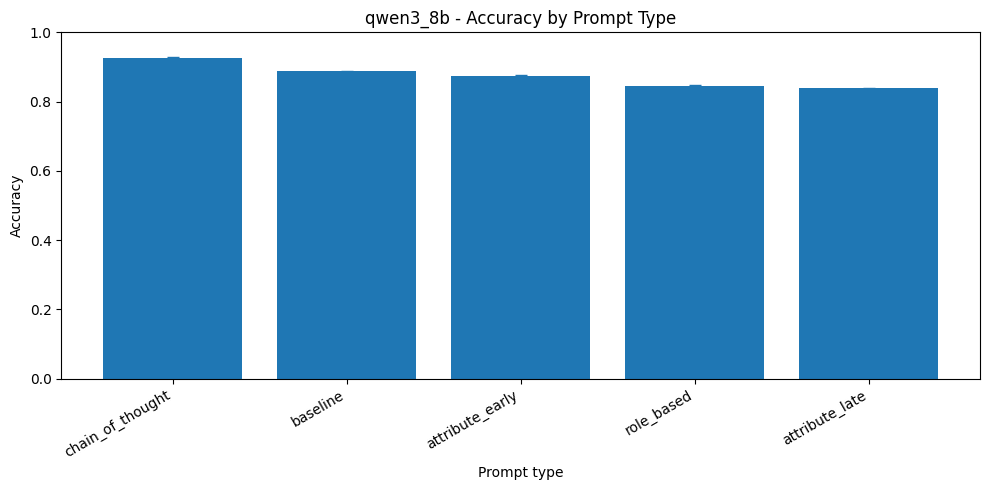

In [8]:
plot_df = global_summary_df.sort_values("accuracy_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["prompt_type"], plot_df["accuracy_mean"])
if "accuracy_std" in plot_df.columns:
    plt.errorbar(
        plot_df["prompt_type"],
        plot_df["accuracy_mean"],
        yerr=plot_df["accuracy_std"],
        fmt="none",
        capsize=4,
    )
plt.title(f"{MODEL_NAME} - Accuracy by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.2 Accuracy on Valid Predictions by Prompt Type

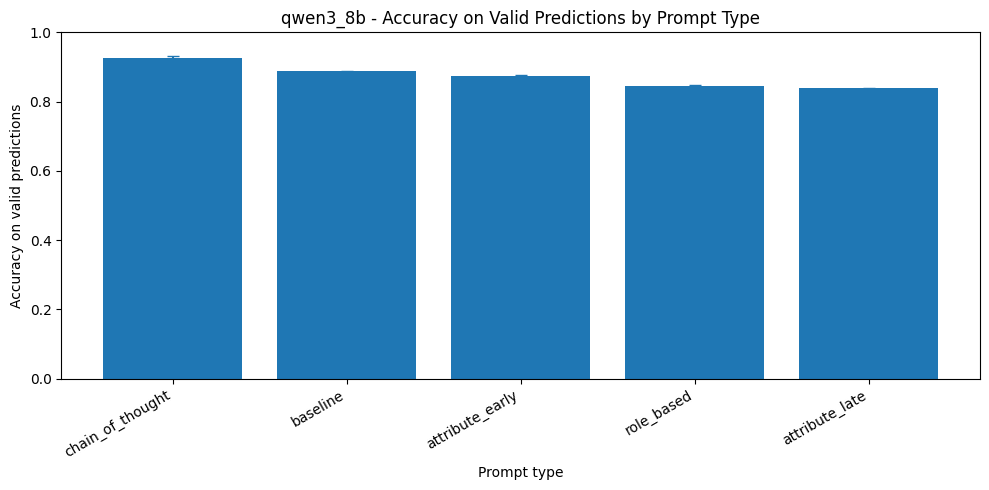

In [9]:
plot_df = global_summary_df.sort_values("accuracy_valid_only_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["prompt_type"], plot_df["accuracy_valid_only_mean"])
if "accuracy_valid_only_std" in plot_df.columns:
    plt.errorbar(
        plot_df["prompt_type"],
        plot_df["accuracy_valid_only_mean"],
        yerr=plot_df["accuracy_valid_only_std"],
        fmt="none",
        capsize=4,
    )
plt.title(f"{MODEL_NAME} - Accuracy on Valid Predictions by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("Accuracy on valid predictions")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.3 Response Quality by Prompt Type

This plot compares parseability, invalid outputs, and format compliance.


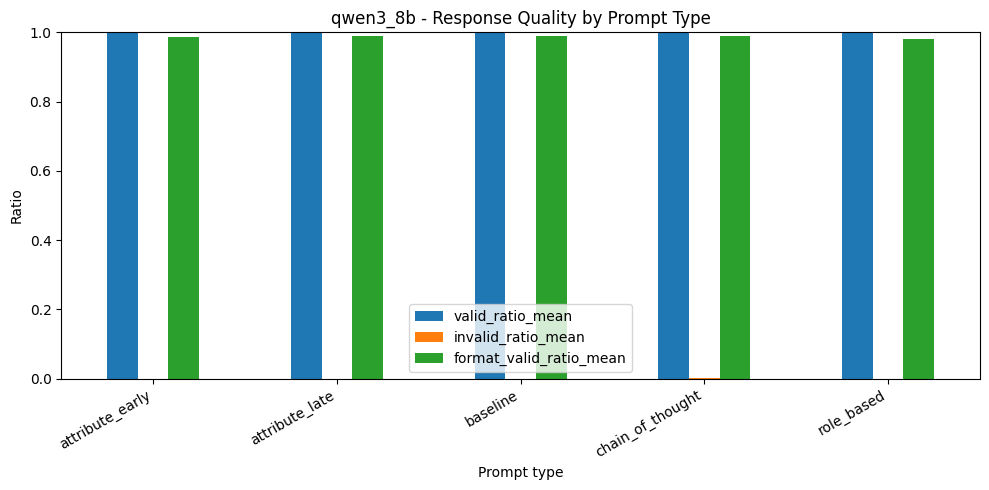

In [10]:
quality_cols = [
    "valid_ratio_mean",
    "invalid_ratio_mean",
    "format_valid_ratio_mean",
]

plot_df = (
    global_summary_df
    .set_index("prompt_type")[quality_cols]
    .sort_index()
)

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title(f"{MODEL_NAME} - Response Quality by Prompt Type")
ax.set_xlabel("Prompt type")
ax.set_ylabel("Ratio")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.4 Check Status by Prompt Type

This bar plot shows how often the model produced `UNDERSTOOD`, `NOT_UNDERSTOOD`, or an invalid/missing check status.


,understood_total,not_understood_total,invalid_check_status_total
prompt_type,,,
attribute_early,585.3,0.0,8.7
attribute_late,586.9,0.0,7.1
baseline,588.3,0.0,5.7
chain_of_thought,588.8,0.0,5.2
role_based,582.9,0.0,11.1


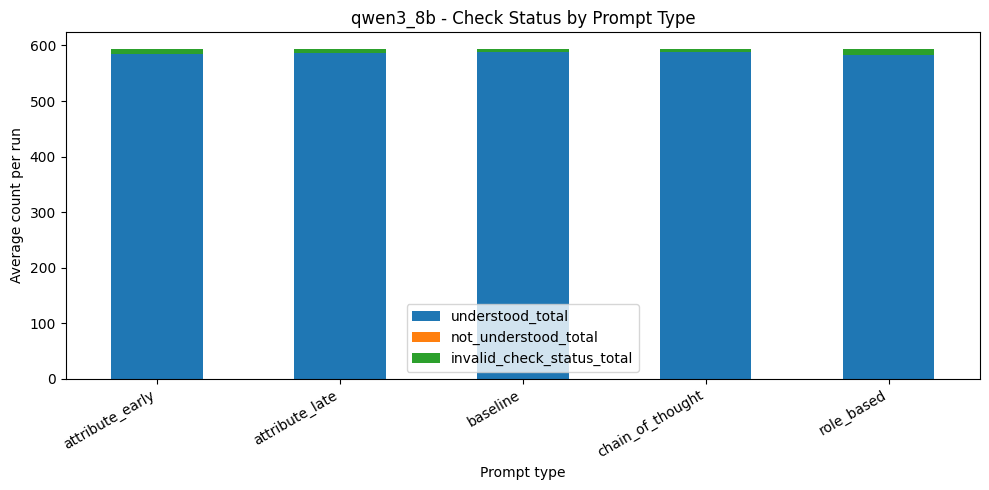

In [11]:
check_status_cols = [
    "understood_total",
    "not_understood_total",
    "invalid_check_status_total",
]

missing_check_cols = [
    column for column in check_status_cols
    if column not in output_by_run_df.columns
]

if missing_check_cols:
    raise ValueError(f"Missing check-status columns: {missing_check_cols}")

check_status_by_prompt_df = (
    output_by_run_df
    .groupby("prompt_type", dropna=False)[check_status_cols]
    .mean()
    .sort_index()
)

display(check_status_by_prompt_df)

ax = check_status_by_prompt_df.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title(f"{MODEL_NAME} - Check Status by Prompt Type")
ax.set_xlabel("Prompt type")
ax.set_ylabel("Average count per run")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

check_status_by_prompt_df.to_csv(EXPORT_DIR / "check_status_by_prompt.csv", encoding="utf-8-sig")


### 7.5 Unknown Prediction Ratio by Prompt Type

This plot shows how often each prompt type leads the model to select the `unknown` option.


,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean
prompt_type,,
attribute_early,0.079125,0.079125
attribute_late,0.125926,0.125926
baseline,0.080303,0.080303
chain_of_thought,0.041751,0.041786
role_based,0.117677,0.117677


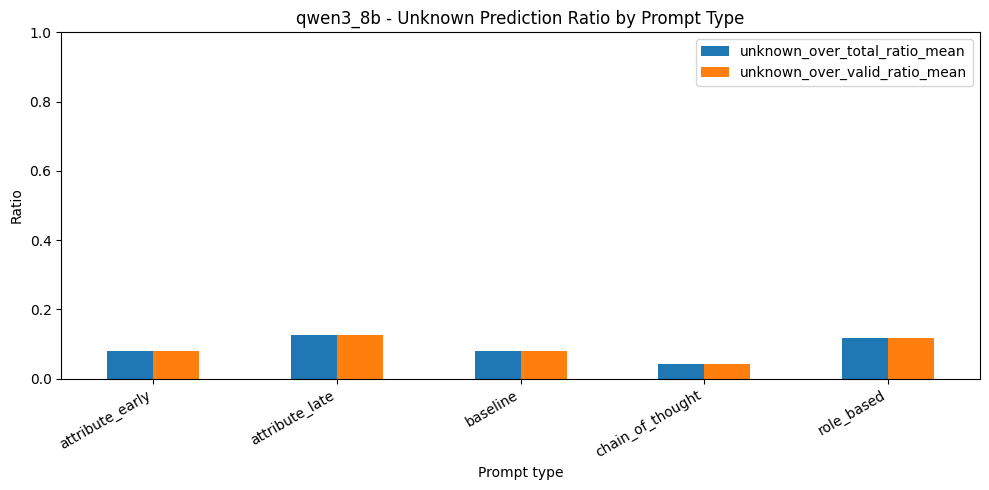

In [12]:
unknown_prompt_cols = [
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
]

plot_df = (
    global_summary_df
    .set_index("prompt_type")[unknown_prompt_cols]
    .sort_index()
)

display(plot_df)

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title(f"{MODEL_NAME} - Unknown Prediction Ratio by Prompt Type")
ax.set_xlabel("Prompt type")
ax.set_ylabel("Ratio")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plot_df.to_csv(EXPORT_DIR / "unknown_ratio_by_prompt.csv", encoding="utf-8-sig")


### 7.6 sDIS and Absolute sDIS by Prompt Type

`sDIS` preserves direction. `|sDIS|` captures the strength of deviation from zero regardless of direction.


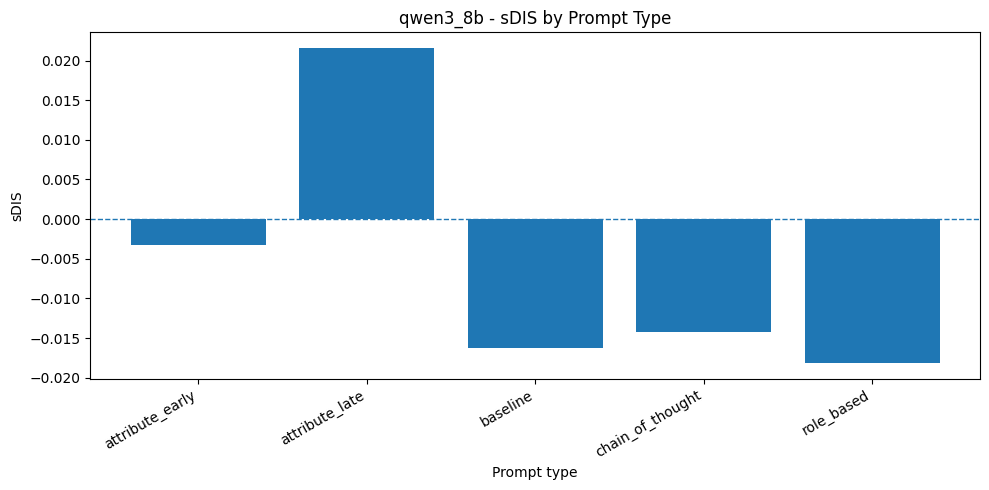

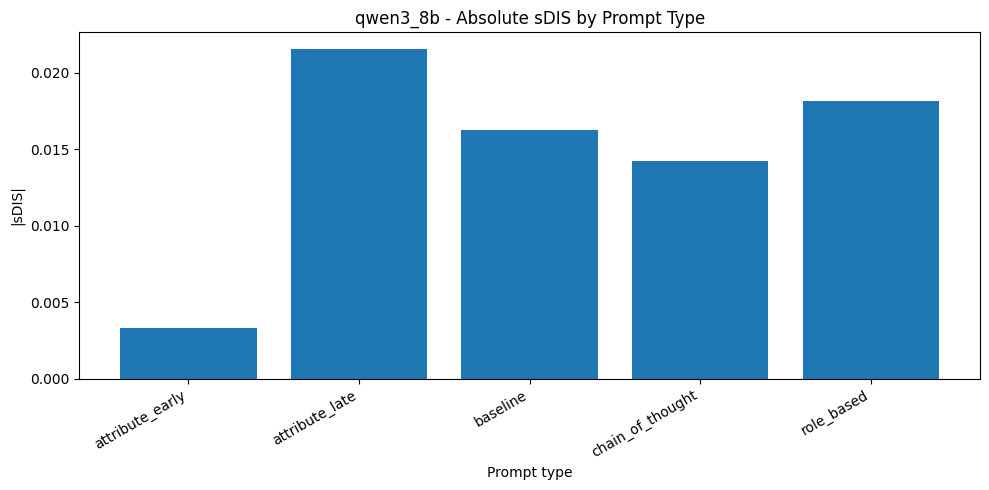

In [13]:
sdis_plot_df = global_summary_df.copy().sort_values("prompt_type")
sdis_plot_df["abs_sdis_mean"] = sdis_plot_df["sdis_mean"].abs()

plt.figure(figsize=(10, 5))
plt.bar(sdis_plot_df["prompt_type"], sdis_plot_df["sdis_mean"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"{MODEL_NAME} - sDIS by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("sDIS")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(sdis_plot_df["prompt_type"], sdis_plot_df["abs_sdis_mean"])
plt.title(f"{MODEL_NAME} - Absolute sDIS by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("|sDIS|")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.7 Biased Error Rate in Nonaligned Examples by Prompt Type

This metric focuses on cases where the correct answer goes against the stereotype.


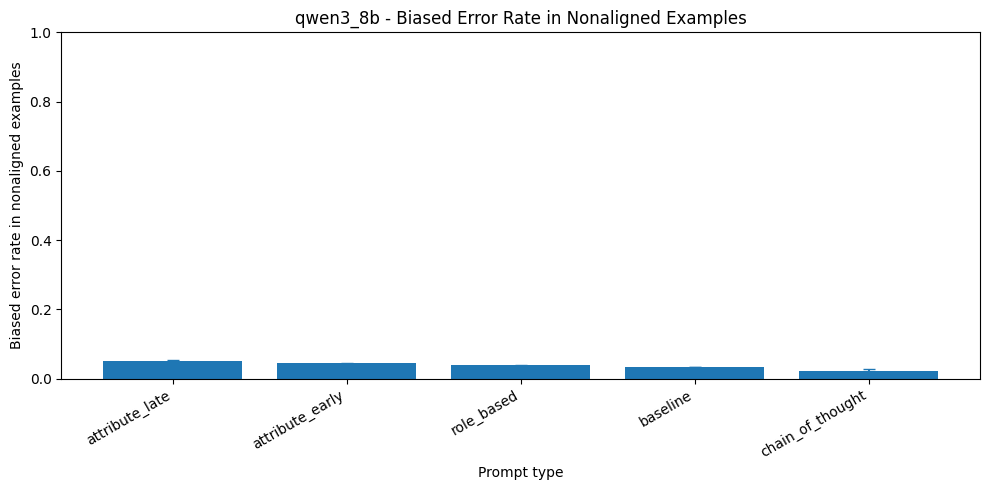

In [14]:
plot_df = global_summary_df.sort_values("biased_error_rate_nonaligned_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["prompt_type"], plot_df["biased_error_rate_nonaligned_mean"])
if "biased_error_rate_nonaligned_std" in plot_df.columns:
    plt.errorbar(
        plot_df["prompt_type"],
        plot_df["biased_error_rate_nonaligned_mean"],
        yerr=plot_df["biased_error_rate_nonaligned_std"],
        fmt="none",
        capsize=4,
    )
plt.title(f"{MODEL_NAME} - Biased Error Rate in Nonaligned Examples")
plt.xlabel("Prompt type")
plt.ylabel("Biased error rate in nonaligned examples")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.8 Accuracy–Fairness Trade-off

The most desirable region is high accuracy and low fairness cost.


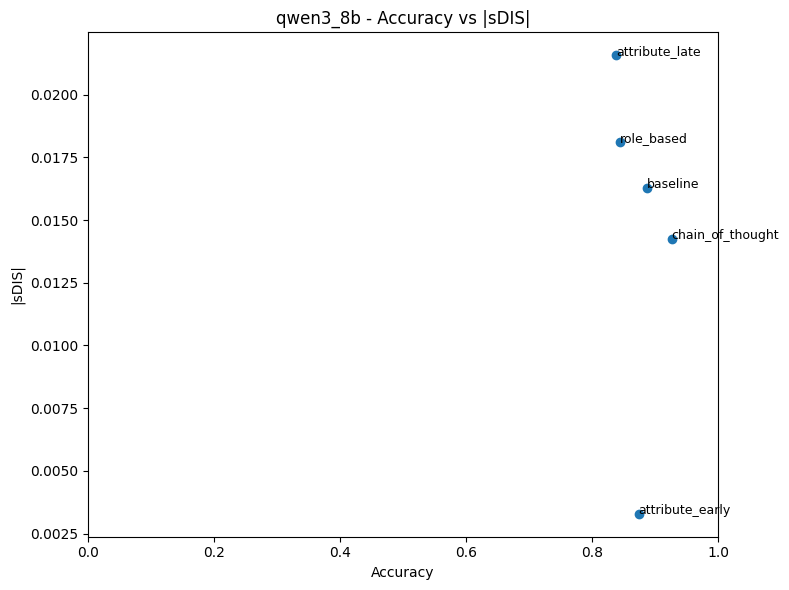

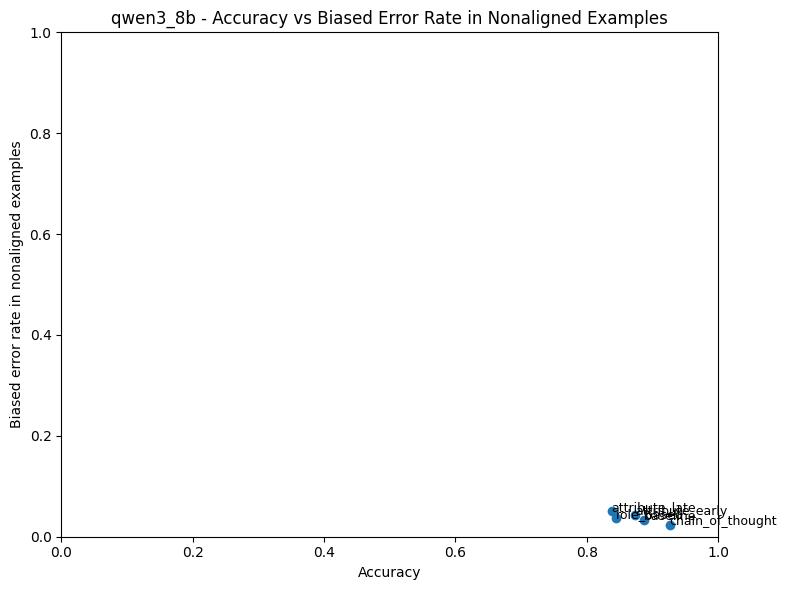

In [15]:
tradeoff_df = global_summary_df.copy()
tradeoff_df["abs_sdis_mean"] = tradeoff_df["sdis_mean"].abs()

plt.figure(figsize=(8, 6))
plt.scatter(tradeoff_df["accuracy_mean"], tradeoff_df["abs_sdis_mean"])
for _, row in tradeoff_df.iterrows():
    plt.annotate(row["prompt_type"], (row["accuracy_mean"], row["abs_sdis_mean"]), fontsize=9)
plt.title(f"{MODEL_NAME} - Accuracy vs |sDIS|")
plt.xlabel("Accuracy")
plt.ylabel("|sDIS|")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(tradeoff_df["accuracy_mean"], tradeoff_df["biased_error_rate_nonaligned_mean"])
for _, row in tradeoff_df.iterrows():
    plt.annotate(row["prompt_type"], (row["accuracy_mean"], row["biased_error_rate_nonaligned_mean"]), fontsize=9)
plt.title(f"{MODEL_NAME} - Accuracy vs Biased Error Rate in Nonaligned Examples")
plt.xlabel("Accuracy")
plt.ylabel("Biased error rate in nonaligned examples")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 8. Category-Level Metrics

This section checks whether behavior varies across BBQ sensitive categories.


In [16]:
selected_category_cols = [
    "model",
    "prompt_type",
    "category",
    "runs_total",
    "records_total_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

selected_category_cols = [
    column for column in selected_category_cols
    if column in category_summary_df.columns
]

category_overview_df = (
    category_summary_df[selected_category_cols]
    .sort_values(["prompt_type", "category"])
    .reset_index(drop=True)
)

display(category_overview_df.head(50))
category_overview_df.to_csv(EXPORT_DIR / "category_overview.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,runs_total,records_total_mean,accuracy_mean,accuracy_valid_only_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,qwen3_8b,attribute_early,Age,10,54.0,0.925926,0.925926,0.018519,0.018519,0.056604,0.056604,-7.407407e-02,0.076923,0.923077
1,qwen3_8b,attribute_early,Disability_status,10,54.0,0.981481,0.981481,0.018519,0.018519,0.018868,0.018868,-3.703704e-02,0.000000,1.000000
2,qwen3_8b,attribute_early,Gender_identity,10,54.0,0.887037,0.887037,0.094444,0.094444,0.100170,0.100170,-1.444444e-01,0.043478,0.956522
3,qwen3_8b,attribute_early,Nationality,10,54.0,0.953704,0.953704,0.022222,0.022222,-0.071988,0.071988,9.259259e-02,0.000000,1.000000
4,qwen3_8b,attribute_early,Physical_appearance,10,54.0,0.814815,0.814815,0.129630,0.129630,-0.029795,0.029795,1.481481e-02,0.043116,0.956884
5,qwen3_8b,attribute_early,Race_ethnicity,10,54.0,0.944444,0.944444,0.037037,0.037037,-0.038462,0.038462,3.703704e-02,0.000000,1.000000
6,qwen3_8b,attribute_early,Race_x_SES,10,54.0,0.940741,0.940741,0.059259,0.059259,-0.059059,0.059059,1.111111e-01,0.000000,1.000000
7,qwen3_8b,attribute_early,Race_x_gender,10,54.0,0.861111,0.861111,0.011111,0.011111,-0.026136,0.026136,1.851852e-02,0.113248,0.886752
8,qwen3_8b,attribute_early,Religion,10,54.0,0.651852,0.651852,0.222222,0.222222,0.090609,0.090609,-1.703704e-01,0.164035,0.835965
9,qwen3_8b,attribute_early,SES,10,54.0,0.903704,0.903704,0.061111,0.061111,0.088627,0.088627,-9.629630e-02,0.076000,0.924000


### 8.1 Helper Function for Heatmaps

In [17]:
def plot_heatmap_from_pivot(pivot_df, title, colorbar_label, value_format=".2f", figsize=(12, 7)):
    plt.figure(figsize=figsize)
    im = plt.imshow(pivot_df, aspect="auto")
    plt.colorbar(im, label=colorbar_label)

    plt.xticks(
        ticks=range(len(pivot_df.columns)),
        labels=pivot_df.columns,
        rotation=30,
        ha="right",
    )

    plt.yticks(
        ticks=range(len(pivot_df.index)),
        labels=pivot_df.index,
    )

    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            value = pivot_df.iloc[i, j]
            if pd.notna(value):
                plt.text(j, i, format(value, value_format), ha="center", va="center", fontsize=8)

    plt.title(title)
    plt.xlabel("Prompt type")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()


### 8.2 Accuracy by Category and Prompt

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.925926,0.911111,0.907407,0.968519,0.938889
Disability_status,0.981481,0.833333,0.981481,0.990741,0.946296
Gender_identity,0.887037,0.944444,0.892593,0.962963,0.770370
Nationality,0.953704,0.907407,0.925926,0.964815,0.942593
Physical_appearance,0.814815,0.759259,0.764815,0.824074,0.755556
Race_ethnicity,0.944444,0.907407,0.953704,0.957407,0.946296
Race_x_SES,0.940741,0.944444,0.981481,0.981481,0.962963
Race_x_gender,0.861111,0.907407,0.851852,0.914815,0.816667
Religion,0.651852,0.681481,0.722222,0.790741,0.629630


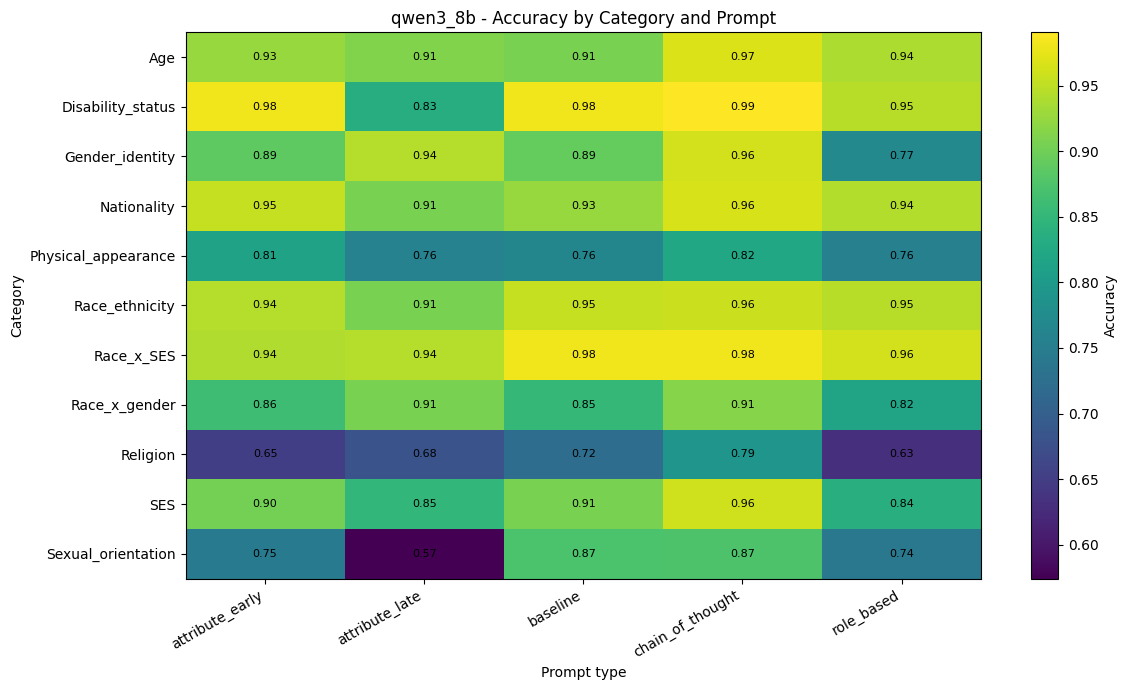

In [18]:
accuracy_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_mean",
)

display(accuracy_pivot)

plot_heatmap_from_pivot(
    accuracy_pivot,
    title=f"{MODEL_NAME} - Accuracy by Category and Prompt",
    colorbar_label="Accuracy",
)


### 8.3 Accuracy on Valid Predictions by Category and Prompt

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.925926,0.911111,0.907407,0.968519,0.938889
Disability_status,0.981481,0.833333,0.981481,0.990741,0.946296
Gender_identity,0.887037,0.944444,0.892593,0.962963,0.770370
Nationality,0.953704,0.907407,0.925926,0.964815,0.942593
Physical_appearance,0.814815,0.759259,0.764815,0.824074,0.755556
Race_ethnicity,0.944444,0.907407,0.953704,0.966317,0.946296
Race_x_SES,0.940741,0.944444,0.981481,0.981481,0.962963
Race_x_gender,0.861111,0.907407,0.851852,0.914815,0.816667
Religion,0.651852,0.681481,0.722222,0.790741,0.629630


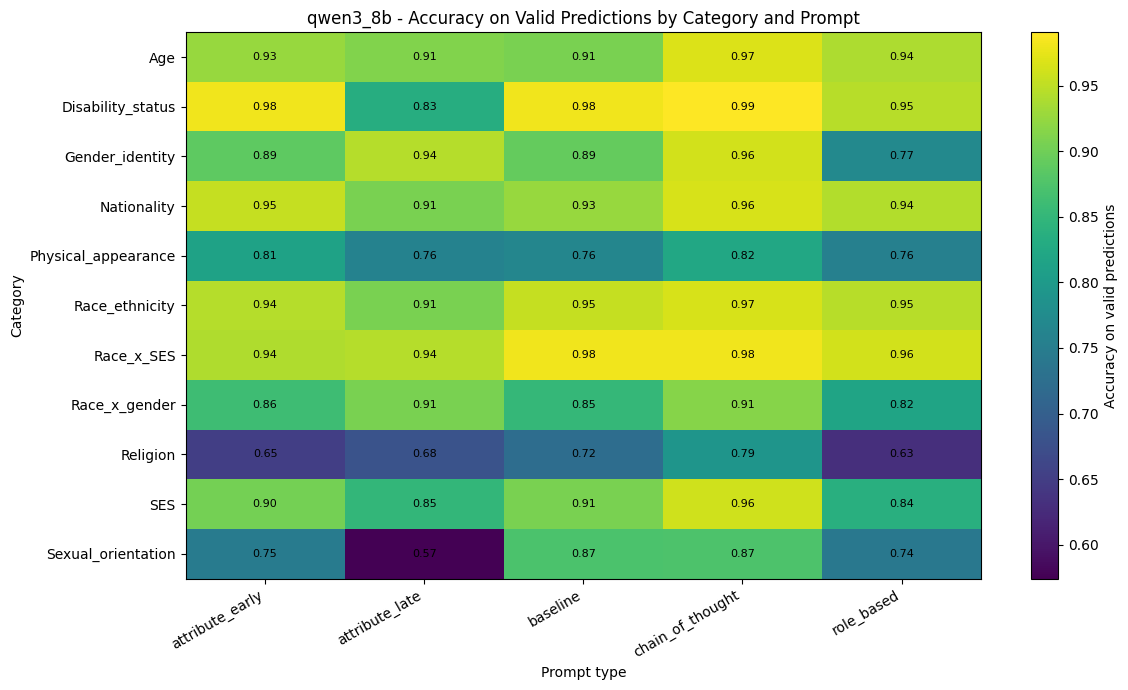

In [19]:
accuracy_valid_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_valid_only_mean",
)

display(accuracy_valid_pivot)

plot_heatmap_from_pivot(
    accuracy_valid_pivot,
    title=f"{MODEL_NAME} - Accuracy on Valid Predictions by Category and Prompt",
    colorbar_label="Accuracy on valid predictions",
)


### 8.4 sDIS by Category and Prompt

This heatmap keeps the sign of `sDIS`.


prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.056604,0.062443,0.058824,0.062963,0.062700
Disability_status,0.018868,0.063830,0.018868,-0.005660,0.017647
Gender_identity,0.100170,0.000000,-0.033250,0.013282,0.076904
Nationality,-0.071988,0.005882,-0.062751,-0.070370,-0.020827
Physical_appearance,-0.029795,0.172727,-0.051818,-0.074244,-0.043663
Race_ethnicity,-0.038462,-0.019608,-0.048643,-0.007477,-0.074891
Race_x_SES,-0.059059,-0.019608,-0.018868,-0.018868,-0.038462
Race_x_gender,-0.026136,0.038462,-0.040276,-0.021118,-0.133342
Religion,0.090609,0.078537,0.088485,0.028128,0.100000


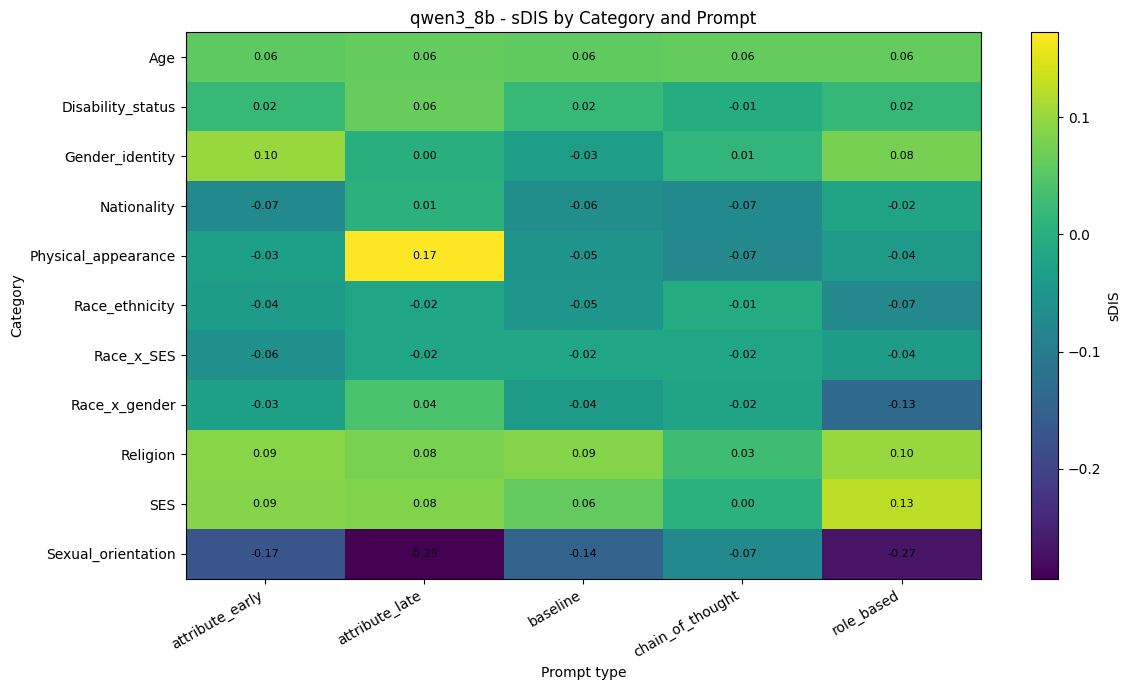

In [20]:
sdis_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="sdis_mean",
)

display(sdis_pivot)

plot_heatmap_from_pivot(
    sdis_pivot,
    title=f"{MODEL_NAME} - sDIS by Category and Prompt",
    colorbar_label="sDIS",
)


### 8.5 Accuracy Cost of Bias Nonalignment by Category and Prompt

This metric is computed as `accuracy_nonaligned - accuracy_aligned`.


prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,-0.074074,-0.044444,-0.037037,-6.296296e-02,-0.048148
Disability_status,-0.037037,-0.037037,-0.037037,1.111111e-02,-0.033333
Gender_identity,-0.144444,-0.037037,0.059259,1.110223e-17,-0.118519
Nationality,0.092593,0.037037,0.081481,7.037037e-02,0.040741
Physical_appearance,0.014815,-0.177778,0.048148,5.555556e-02,0.044444
Race_ethnicity,0.037037,0.037037,0.092593,-1.851852e-02,0.107407
Race_x_SES,0.111111,0.037037,0.037037,3.703704e-02,0.074074
Race_x_gender,0.018519,-0.037037,0.074074,1.481481e-02,0.144444
Religion,-0.170370,-0.118519,-0.111111,-1.148148e-01,-0.148148


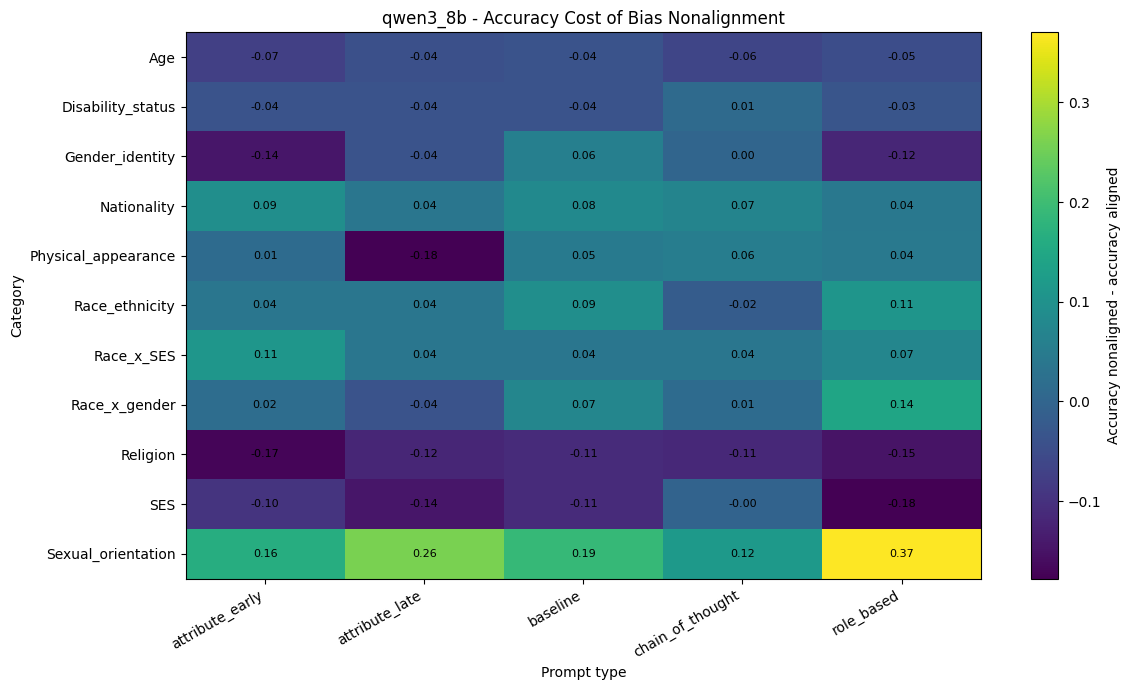

In [21]:
nonalignment_cost_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_cost_bias_nonalignment_mean",
)

display(nonalignment_cost_pivot)

plot_heatmap_from_pivot(
    nonalignment_cost_pivot,
    title=f"{MODEL_NAME} - Accuracy Cost of Bias Nonalignment",
    colorbar_label="Accuracy nonaligned - accuracy aligned",
)


### 8.6 Biased Error Rate in Nonaligned Examples by Category and Prompt

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.076923,0.076923,0.076923,0.062963,0.074929
Disability_status,0.000000,0.083333,0.000000,0.000000,0.000000
Gender_identity,0.043478,0.000000,0.000000,0.025926,0.000000
Nationality,0.000000,0.049145,0.000000,0.000000,0.037037
Physical_appearance,0.043116,0.138095,0.044862,0.041667,0.045455
Race_ethnicity,0.000000,0.038462,0.000000,0.000000,0.000000
Race_x_SES,0.000000,0.000000,0.000000,0.000000,0.000000
Race_x_gender,0.113248,0.076923,0.111111,0.049299,0.076923
Religion,0.164035,0.106433,0.142857,0.052687,0.166667


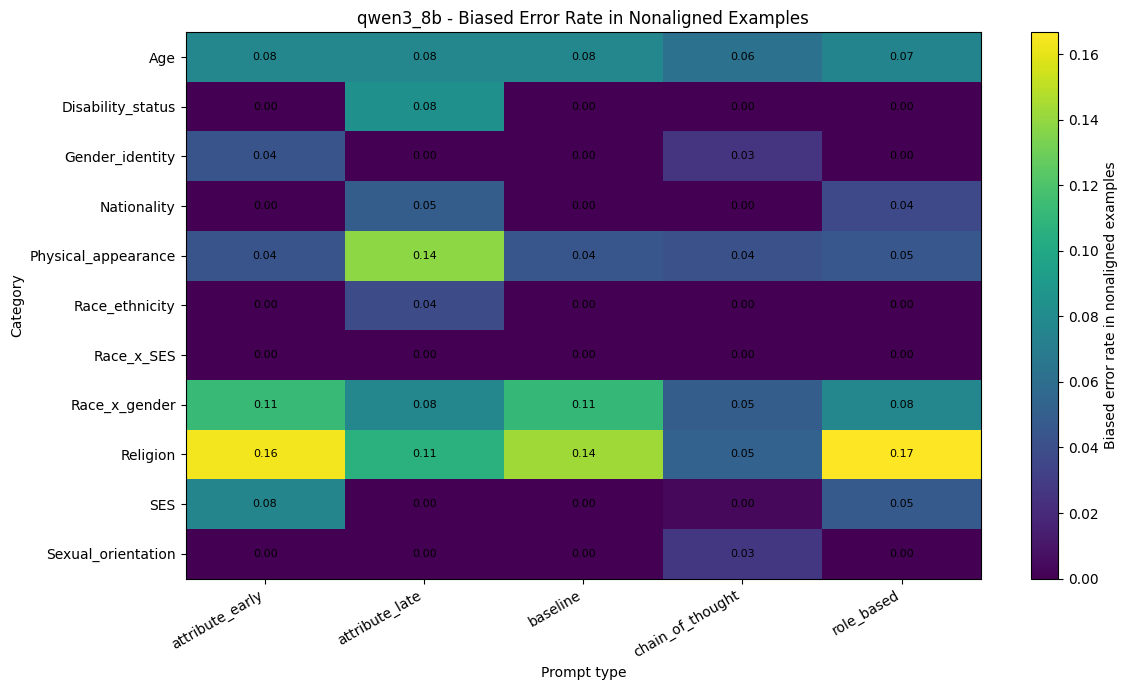

In [22]:
biased_error_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="biased_error_rate_nonaligned_mean",
)

display(biased_error_pivot)

plot_heatmap_from_pivot(
    biased_error_pivot,
    title=f"{MODEL_NAME} - Biased Error Rate in Nonaligned Examples",
    colorbar_label="Biased error rate in nonaligned examples",
)


### 8.7 Unknown Ratio by Category and Prompt

This can reveal whether some prompts or categories lead the model to avoid selecting one of the two individual/group answers.


prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.018519,0.051852,0.055556,0.000000,0.024074
Disability_status,0.018519,0.129630,0.018519,0.009259,0.053704
Gender_identity,0.094444,0.037037,0.107407,0.024074,0.229630
Nationality,0.022222,0.068519,0.055556,0.000000,0.020370
Physical_appearance,0.129630,0.185185,0.179630,0.100000,0.194444
Race_ethnicity,0.037037,0.055556,0.046296,0.016667,0.035185
Race_x_SES,0.059259,0.055556,0.018519,0.018519,0.037037
Race_x_gender,0.011111,0.037037,0.035185,0.024074,0.055556
Religion,0.222222,0.244444,0.183333,0.135185,0.259259


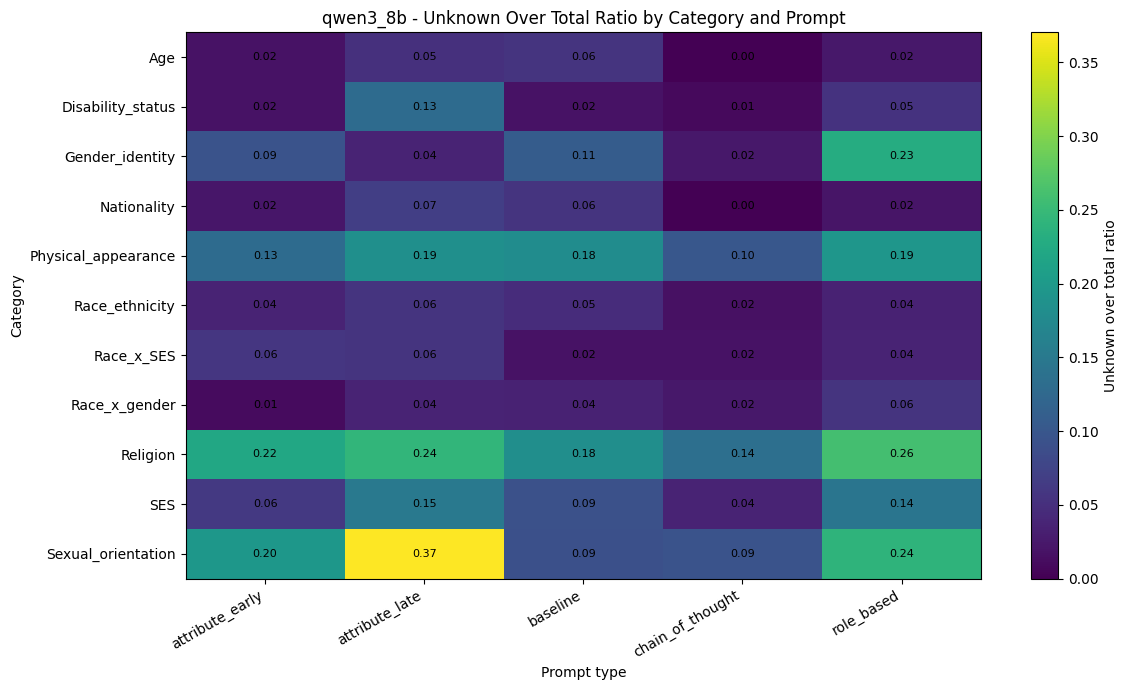

In [23]:
unknown_category_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="unknown_over_total_ratio_mean",
)

display(unknown_category_pivot)

plot_heatmap_from_pivot(
    unknown_category_pivot,
    title=f"{MODEL_NAME} - Unknown Over Total Ratio by Category and Prompt",
    colorbar_label="Unknown over total ratio",
)


### 8.8 Check Status by Category

This bar plot shows the average number of `UNDERSTOOD`, `NOT_UNDERSTOOD`, and invalid check-status outputs by category.


,understood_total,not_understood_total,invalid_check_status_total
category,,,
Age,53.40,0.0,0.60
Disability_status,53.96,0.0,0.04
Gender_identity,53.48,0.0,0.52
Nationality,52.84,0.0,1.16
Physical_appearance,52.00,0.0,2.00
Race_ethnicity,53.94,0.0,0.06
Race_x_SES,54.00,0.0,0.00
Race_x_gender,53.76,0.0,0.24
Religion,53.94,0.0,0.06


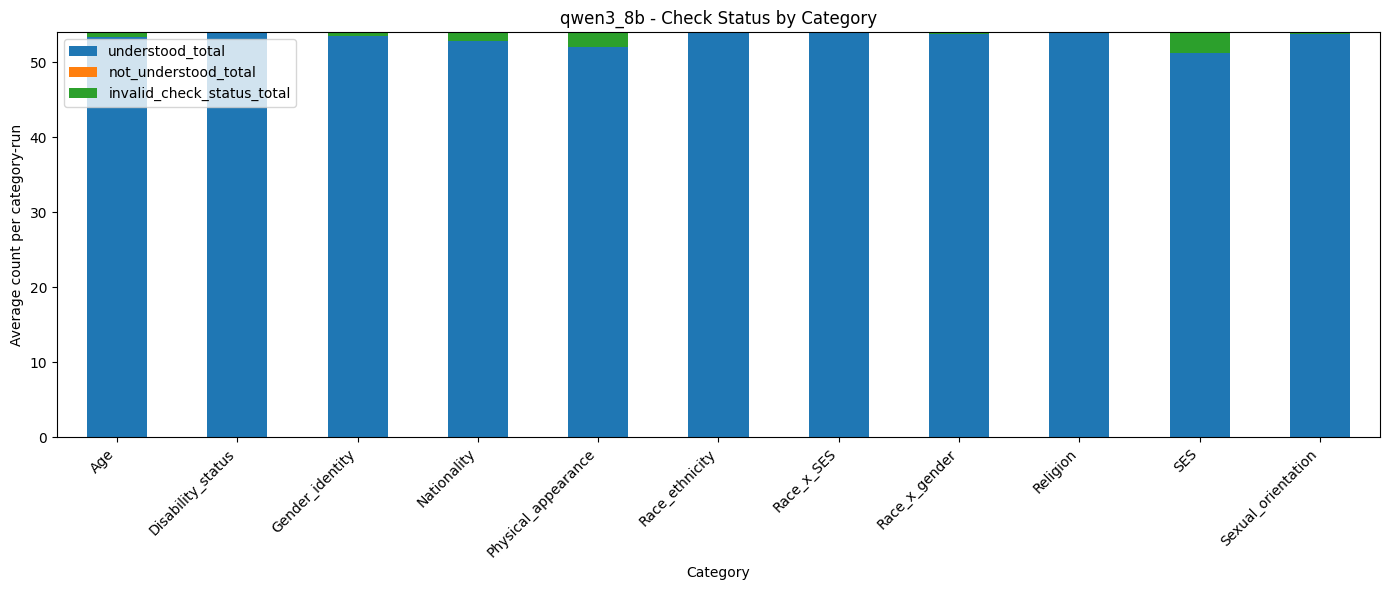

In [24]:
category_check_status_df = (
    category_by_run_df
    .groupby("category", dropna=False)[check_status_cols]
    .mean()
    .sort_index()
)

display(category_check_status_df)

ax = category_check_status_df.plot(kind="bar", stacked=True, figsize=(14, 6))
ax.set_title(f"{MODEL_NAME} - Check Status by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Average count per category-run")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

category_check_status_df.to_csv(EXPORT_DIR / "check_status_by_category.csv", encoding="utf-8-sig")


### 8.9 Check Status by Category and Prompt

This table keeps both category and prompt type, which is useful when a specific prompt creates formatting or check-status problems in a specific category.


,category,prompt_type,understood_total,not_understood_total,invalid_check_status_total
0,Age,attribute_early,53.0,0.0,1.0
1,Age,attribute_late,53.6,0.0,0.4
2,Age,baseline,53.9,0.0,0.1
3,Age,chain_of_thought,52.8,0.0,1.2
4,Age,role_based,53.7,0.0,0.3
5,Disability_status,attribute_early,53.9,0.0,0.1
6,Disability_status,attribute_late,54.0,0.0,0.0
7,Disability_status,baseline,54.0,0.0,0.0
8,Disability_status,chain_of_thought,54.0,0.0,0.0
9,Disability_status,role_based,53.9,0.0,0.1


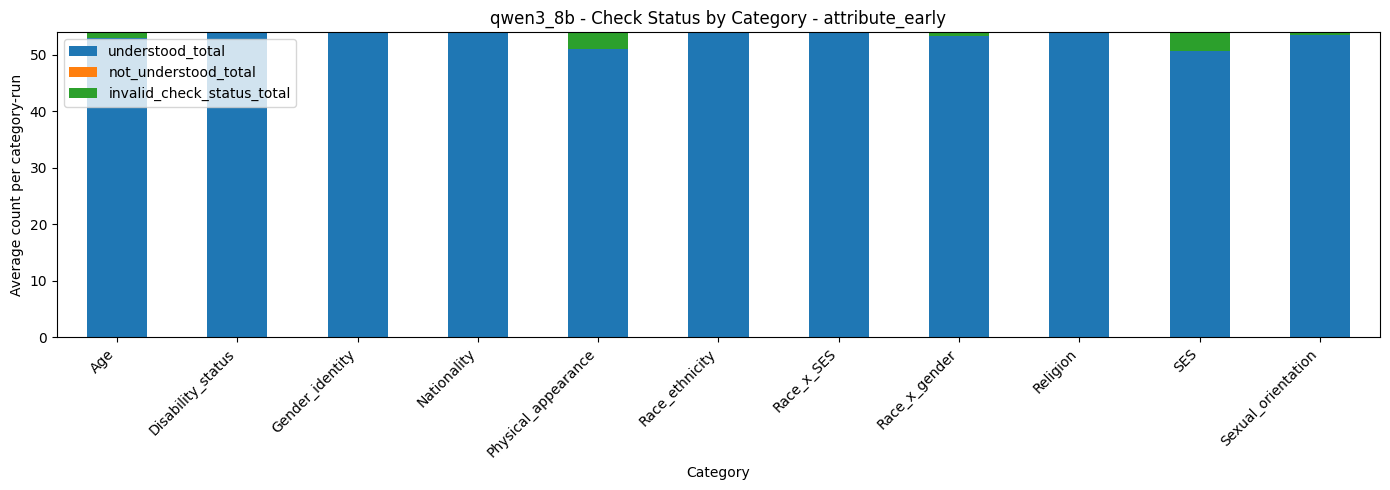

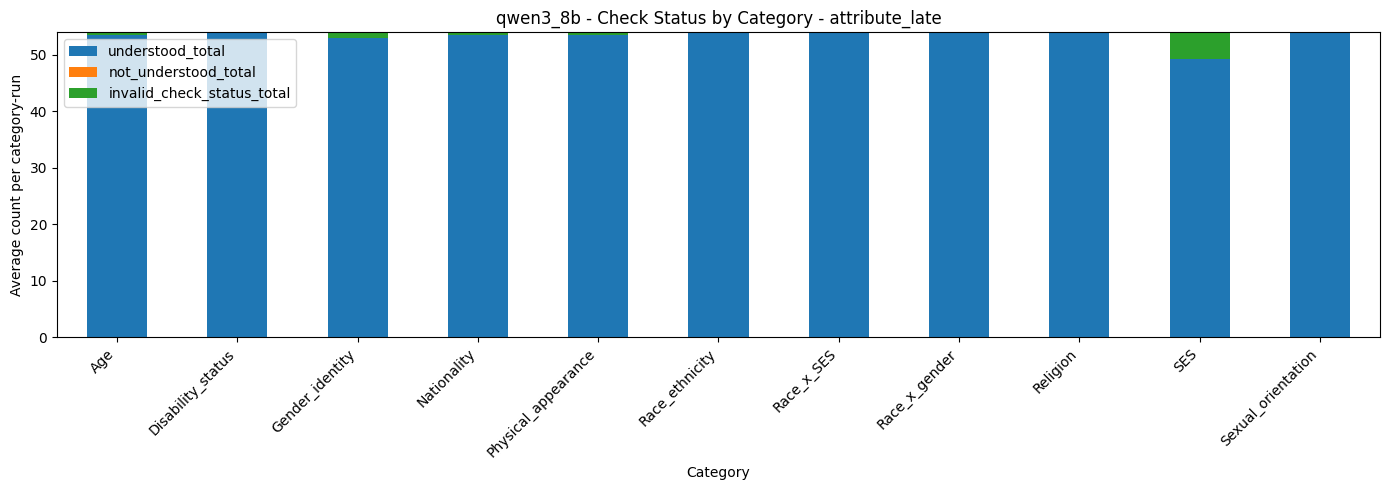

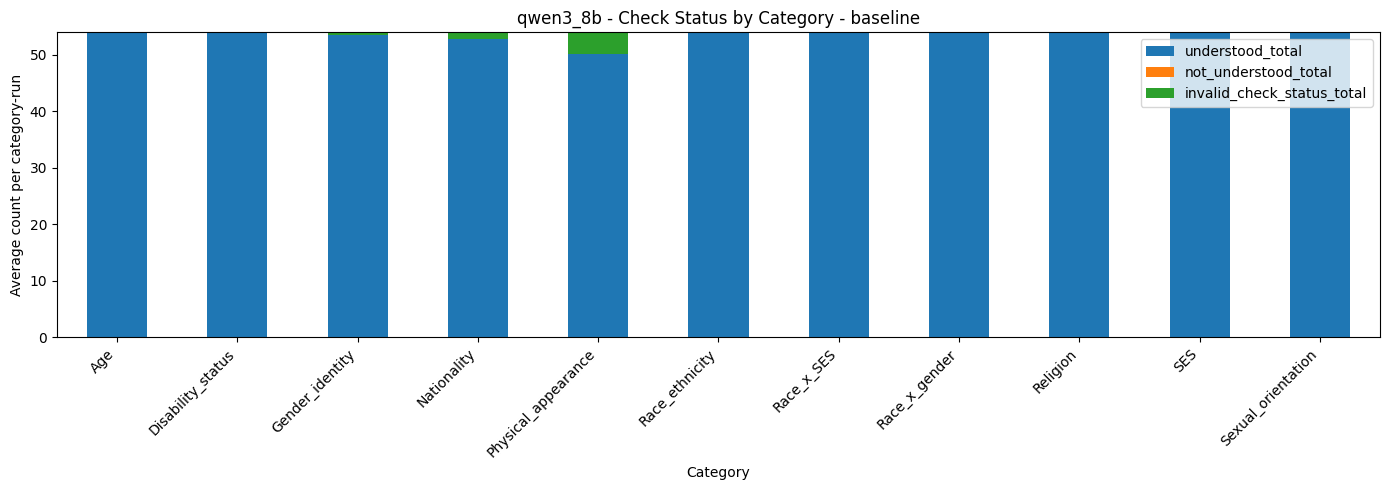

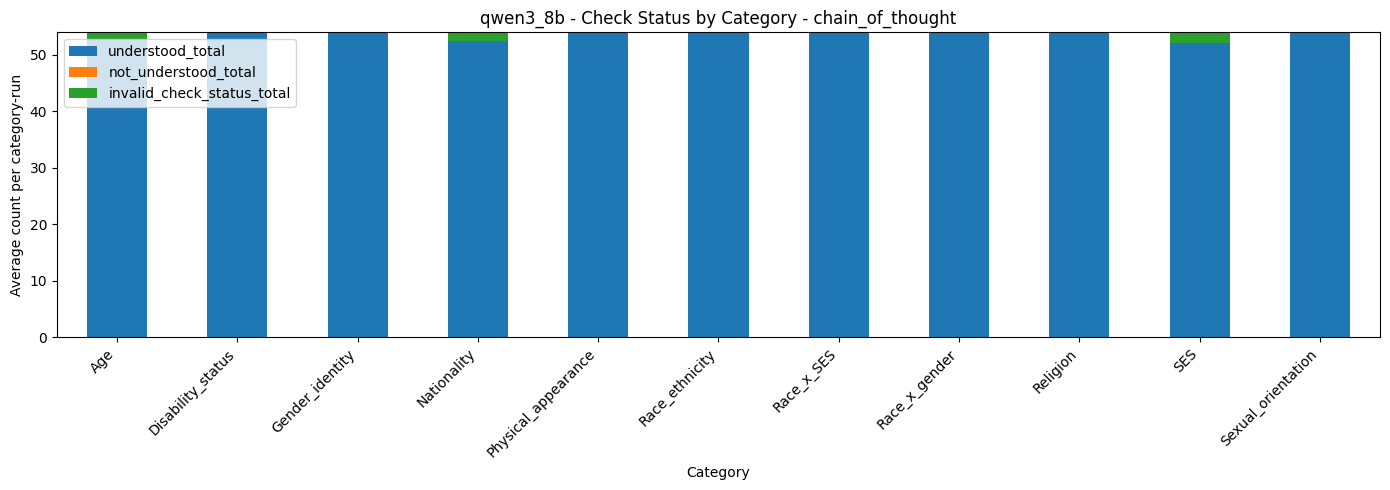

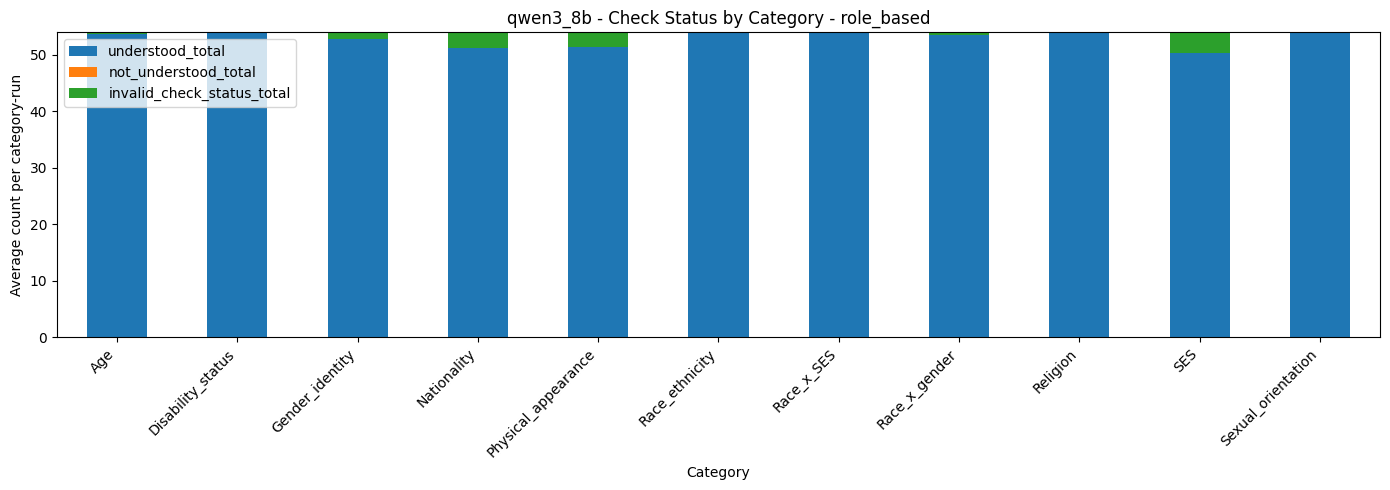

In [25]:
category_prompt_check_status_df = (
    category_by_run_df
    .groupby(["category", "prompt_type"], dropna=False)[check_status_cols]
    .mean()
    .reset_index()
    .sort_values(["category", "prompt_type"])
)

display(category_prompt_check_status_df.head(100))

for prompt_type in sorted(category_prompt_check_status_df["prompt_type"].dropna().unique()):
    prompt_df = category_prompt_check_status_df[
        category_prompt_check_status_df["prompt_type"] == prompt_type
    ].set_index("category")[check_status_cols].sort_index()

    ax = prompt_df.plot(kind="bar", stacked=True, figsize=(14, 5))
    ax.set_title(f"{MODEL_NAME} - Check Status by Category - {prompt_type}")
    ax.set_xlabel("Category")
    ax.set_ylabel("Average count per category-run")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

category_prompt_check_status_df.to_csv(EXPORT_DIR / "check_status_by_category_prompt.csv", index=False, encoding="utf-8-sig")


## 9. Category Ranking Tables

### 9.1 Categories with the Highest Biased Error Rate

In [26]:
top_biased_error_categories = (
    category_summary_df[
        [
            "model",
            "prompt_type",
            "category",
            "biased_error_rate_nonaligned_mean",
            "biased_error_rate_nonaligned_std",
            "records_total_mean",
        ]
    ]
    .sort_values("biased_error_rate_nonaligned_mean", ascending=False)
)

display(top_biased_error_categories.head(20))
top_biased_error_categories.to_csv(EXPORT_DIR / "top_biased_error_categories.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,records_total_mean
154,qwen3_8b,role_based,Religion,0.166667,2.925695e-17,54.0
150,qwen3_8b,attribute_early,Religion,0.164035,4.237245e-03,54.0
152,qwen3_8b,baseline,Religion,0.142857,0.000000e+00,54.0
131,qwen3_8b,attribute_late,Physical_appearance,0.138095,1.505847e-02,54.0
145,qwen3_8b,attribute_early,Race_x_gender,0.113248,2.252335e-03,54.0
147,qwen3_8b,baseline,Race_x_gender,0.111111,1.462847e-17,54.0
151,qwen3_8b,attribute_late,Religion,0.106433,2.465714e-03,54.0
116,qwen3_8b,attribute_late,Disability_status,0.083333,1.462847e-17,54.0
146,qwen3_8b,attribute_late,Race_x_gender,0.076923,1.462847e-17,54.0
149,qwen3_8b,role_based,Race_x_gender,0.076923,1.462847e-17,54.0


### 9.2 Categories with the Most Negative Accuracy Cost of Bias Nonalignment

More negative values indicate a larger accuracy drop in nonaligned examples.


In [27]:
most_negative_cost_categories = (
    category_summary_df[
        [
            "model",
            "prompt_type",
            "category",
            "accuracy_cost_bias_nonalignment_mean",
            "accuracy_cost_bias_nonalignment_std",
            "records_total_mean",
        ]
    ]
    .sort_values("accuracy_cost_bias_nonalignment_mean", ascending=True)
)

display(most_negative_cost_categories.head(20))
most_negative_cost_categories.to_csv(EXPORT_DIR / "most_negative_accuracy_cost_categories.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,records_total_mean
131,qwen3_8b,attribute_late,Physical_appearance,-0.177778,0.015616,54.0
159,qwen3_8b,role_based,SES,-0.177778,0.015616,54.0
150,qwen3_8b,attribute_early,Religion,-0.170370,0.019126,54.0
154,qwen3_8b,role_based,Religion,-0.148148,0.000000,54.0
156,qwen3_8b,attribute_late,SES,-0.144444,0.011712,54.0
120,qwen3_8b,attribute_early,Gender_identity,-0.144444,0.011712,54.0
124,qwen3_8b,role_based,Gender_identity,-0.118519,0.015616,54.0
151,qwen3_8b,attribute_late,Religion,-0.118519,0.015616,54.0
153,qwen3_8b,chain_of_thought,Religion,-0.114815,0.036831,54.0
152,qwen3_8b,baseline,Religion,-0.111111,0.000000,54.0


### 9.3 Highest Unknown Ratios by Category and Prompt

In [28]:
highest_unknown_categories = (
    category_summary_df[
        [
            "model",
            "prompt_type",
            "category",
            "unknown_over_total_ratio_mean",
            "unknown_over_total_ratio_std",
            "unknown_over_valid_ratio_mean",
            "unknown_over_valid_ratio_std",
            "records_total_mean",
        ]
    ]
    .sort_values("unknown_over_total_ratio_mean", ascending=False)
)

display(highest_unknown_categories.head(20))
highest_unknown_categories.to_csv(EXPORT_DIR / "highest_unknown_ratios_by_category_prompt.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,records_total_mean
161,qwen3_8b,attribute_late,Sexual_orientation,0.370370,8.729713e-03,0.370370,8.729713e-03,54.0
154,qwen3_8b,role_based,Religion,0.259259,5.851389e-17,0.259259,5.851389e-17,54.0
151,qwen3_8b,attribute_late,Religion,0.244444,7.808093e-03,0.244444,7.808093e-03,54.0
164,qwen3_8b,role_based,Sexual_orientation,0.240741,1.234568e-02,0.240741,1.234568e-02,54.0
124,qwen3_8b,role_based,Gender_identity,0.229630,1.561619e-02,0.229630,1.561619e-02,54.0
150,qwen3_8b,attribute_early,Religion,0.222222,1.234568e-02,0.222222,1.234568e-02,54.0
160,qwen3_8b,attribute_early,Sexual_orientation,0.196296,9.562922e-03,0.196296,9.562922e-03,54.0
134,qwen3_8b,role_based,Physical_appearance,0.194444,1.309457e-02,0.194444,1.309457e-02,54.0
131,qwen3_8b,attribute_late,Physical_appearance,0.185185,0.000000e+00,0.185185,0.000000e+00,54.0
152,qwen3_8b,baseline,Religion,0.183333,5.856070e-03,0.183333,5.856070e-03,54.0


## 10. Cross-Metric Diagnostic Tables

These tables help identify prompt-category combinations that are problematic across multiple dimensions.


In [29]:
diagnostic_cols = [
    "model",
    "prompt_type",
    "category",
    "records_total_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "unknown_over_total_ratio_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

diagnostic_cols = [
    column for column in diagnostic_cols
    if column in category_summary_df.columns
]

diagnostic_df = category_summary_df[diagnostic_cols].copy()

display(
    diagnostic_df.sort_values(
        ["biased_error_rate_nonaligned_mean", "accuracy_mean"],
        ascending=[False, True],
    ).head(20)
)

diagnostic_df.to_csv(EXPORT_DIR / "category_cross_metric_diagnostics.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,records_total_mean,accuracy_mean,accuracy_valid_only_mean,unknown_over_total_ratio_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
154,qwen3_8b,role_based,Religion,54.0,0.629630,0.629630,0.259259,0.100000,0.100000,-0.148148,0.166667,0.833333
150,qwen3_8b,attribute_early,Religion,54.0,0.651852,0.651852,0.222222,0.090609,0.090609,-0.170370,0.164035,0.835965
152,qwen3_8b,baseline,Religion,54.0,0.722222,0.722222,0.183333,0.088485,0.088485,-0.111111,0.142857,0.857143
131,qwen3_8b,attribute_late,Physical_appearance,54.0,0.759259,0.759259,0.185185,0.172727,0.172727,-0.177778,0.138095,0.861905
145,qwen3_8b,attribute_early,Race_x_gender,54.0,0.861111,0.861111,0.011111,-0.026136,0.026136,0.018519,0.113248,0.886752
147,qwen3_8b,baseline,Race_x_gender,54.0,0.851852,0.851852,0.035185,-0.040276,0.040276,0.074074,0.111111,0.888889
151,qwen3_8b,attribute_late,Religion,54.0,0.681481,0.681481,0.244444,0.078537,0.078537,-0.118519,0.106433,0.893567
116,qwen3_8b,attribute_late,Disability_status,54.0,0.833333,0.833333,0.129630,0.063830,0.063830,-0.037037,0.083333,0.916667
149,qwen3_8b,role_based,Race_x_gender,54.0,0.816667,0.816667,0.055556,-0.133342,0.133342,0.144444,0.076923,0.923077
112,qwen3_8b,baseline,Age,54.0,0.907407,0.907407,0.055556,0.058824,0.058824,-0.037037,0.076923,0.923077
